In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('dark_background')
sns.set_palette("pastel")

# 2. Load the required tables from the extracted folder
photos_df = pd.read_csv('/content/photos.csv')
likes_df = pd.read_csv('/content/likes.csv')
comments_df = pd.read_csv('/content/comments.csv')
follows_df = pd.read_csv('/content/follows.csv')
tags_df = pd.read_csv('/content/tags.csv')
photo_tags_df = pd.read_csv('/content/photo_tags.csv')

print("All 6 tables loaded successfully!")

All 6 tables loaded successfully!


In [7]:
# 1. Rename columns right away so they all match perfectly across tables
if 'photo' in likes_df.columns:
    likes_df.rename(columns={'photo': 'photo_id'}, inplace=True)

if 'followee' in follows_df.columns:
    follows_df.rename(columns={'followee': 'user_id'}, inplace=True)

# photos_df uses 'id' instead of 'photo_id'
date_col = 'created_at' if 'created_at' in photos_df.columns else 'created_dat'
if 'id' in photos_df.columns:
    photos_df.rename(columns={'id': 'photo_id', date_col: 'Date'}, inplace=True)


# 2. Aggregate Likes and Comments per Photo
likes_count = likes_df.groupby('photo_id').size().reset_index(name='Likes')
comments_count = comments_df.groupby('photo_id').size().reset_index(name='Comments')


# 3. Aggregate Followers per User
followers_count = follows_df.groupby('user_id').size().reset_index(name='Followers')


# 4. Merge dataframes around the main 'photos' table
df = photos_df.merge(followers_count, on='user_id', how='left').fillna({'Followers': 0})
df = df.merge(likes_count, on='photo_id', how='left').fillna({'Likes': 0})
df = df.merge(comments_count, on='photo_id', how='left').fillna({'Comments': 0})


# 5. Parse Dates & Compute Engagement Metric
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Hour_of_Day'] = df['Date'].dt.hour
df['Day_of_Week'] = df['Date'].dt.day_name()

# Prevent division by zero
df['Followers'] = df['Followers'].replace(0, np.nan)

# Calculate Engagement Rate (Standardized as a percentage)
df['Engagement_Rate'] = ((df['Likes'] + df['Comments']) / df['Followers']) * 100

print("Success! Data merged and metrics calculated:")
print(df[['photo_id', 'Likes', 'Comments', 'Followers', 'Engagement_Rate']].head())

Success! Data merged and metrics calculated:
   photo_id  Likes  Comments  Followers  Engagement_Rate
0         1     25        25         77        64.935065
1         2     36        31         77        87.012987
2         3     38        27         77        84.415584
3         4     38        32         77        90.909091
4         5     31        27         77        75.324675


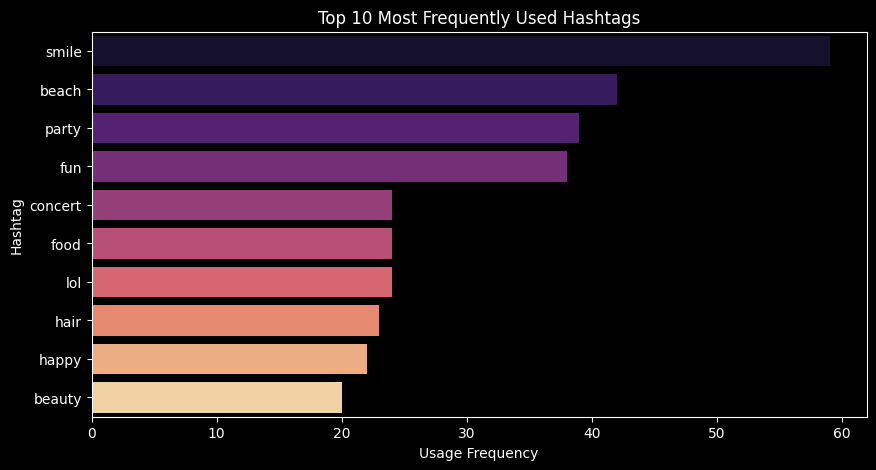

In [10]:
# --- Analyze Hashtags (Bar Chart) ---

# 1. Clean column names to prevent hidden spaces
tags_df.columns = tags_df.columns.str.strip().str.lower().str.replace(' ', '_')
photo_tags_df.columns = photo_tags_df.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Fix the shorthand naming in photo_tags so the merge works
if 'tag' in photo_tags_df.columns:
    photo_tags_df.rename(columns={'tag': 'tag_id'}, inplace=True)

# 3. DYNAMICALLY find the column with the hashtag text.
# We know the tags table has an 'id' column, so the *other* column has to be the text!
text_column = [col for col in tags_df.columns if col != 'id'][0]

# 4. Map the tag_ids to their actual text names
hashtags_merged = photo_tags_df.merge(tags_df, left_on='tag_id', right_on='id')

# Use the dynamically found text column to count the tags
top_tags = hashtags_merged[text_column].value_counts().head(10)

# 5. Plot the bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='magma')
plt.title('Top 10 Most Frequently Used Hashtags')
plt.xlabel('Usage Frequency')
plt.ylabel('Hashtag')
plt.show()